# **Getting Started With the Notebook**

This notebook is organized into **simple, collapsible sections** so you can easily navigate and run only what you need.

#### **Step 1**: Initial Setup
Start by running the **“Initial Setup and Authentication”** section. This prepares everything needed for the notebook to work properly.

#### ⚠️ First-Time Users Only
If this is your **first time opening this workspace**:
1. Run the initial setup  
2. **Restart (relaunch) the workspace**  
3. Run the **“Initial Setup and Authentication”** section again  
> 💡 You only need to do this once per new workspace.

####  **Step 2**: Provide Your Data
Provide the `hubmap_id` for the dataset you want to work with. This tells the notebook which data to use.

#### **Step 3**: Run the Analysis
- Go to any section you want to explore and run the cells in that section 

#### Running Cells
- **Shift + Enter** → Run cell and move to the next one 
- **Ctrl + Enter** → Run cell and stay on the same one

#### Understanding the Sections
- Each section is **independent** → you can run them in any order *(after setup)*  
- Within a section → run cells **from top to bottom**  
- Each section is **self-contained** and labeled to guide you 
> 💡 **Tip:** If you're unsure where to start, just follow the steps in order — everything is designed to guide you along the way.

## Table of Contents

> 💡 **Tip:** Use the **Table of Contents** icon (☰) in the left sidebar to quickly jump between sections.

#### 1. **Getting Started** 
Begin here to set everything up:
1. Initial Setup and Authentication

#### 2. **Data Management**
Use these steps to find and prepare your data:

2. Find and Download to Workspace
3. Push to Fusion Backend   
4. Download from Fusion Backend  

#### 3. **Run Analysis Jobs**
Run different analysis workflows on your data:

5. Available workflows include:
   - Multi-Compartment Segmentation  
   - Frozen Glomerulus Segmentation  
   - Expanded Granular Feature Extraction 
   - Spot Data Generation  
     - Label Transfer  
     - Spot Annotation  
   - Spatial Aggregation

#### 4. **Visualization**
Explore and view your results:

6. Visualize HuBMAP Data  
7. Visualize 10x Visium Spatial-Omics Data from Fusion Backend  

# **FUSION++ Features**

In [ ]:
import os
os.listdir("Images")

![FUSION++_Features](images/FUSION++_Features.png)

# **Initial Setup and Authentication**

In [ ]:
from IPython.display import clear_output

print("⏳ Installing dependencies... this may take a moment.")

!pip install large_image[all] --find-links https://girder.github.io/large_image_wheels
!jupyter server extension enable jupyter_server_proxy

clear_output(wait=True)
print("✅ Installation and setup successful!")

In [ ]:
import getpass

# Authenticate
user_name = input("Enter your username: ")
auth_pass = getpass.getpass("Enter your password: ")

import girder_client
gc = girder_client.GirderClient(apiUrl='https://fusionpub.rc.ufl.edu/api/v1')
try:
    user_info = gc.authenticate(user_name, auth_pass)
    print(f"Login Successful: {user_info['firstName']} {user_info['lastName']} ({user_info['email']})")
except Exception as e:
    print(f"Login Failed: {e}")

# **Data Management Features**

This section contains three key features for working with your dataset:

- **1. Find and Download the Dataset to the Workspace** : Downloads one or more HuBMAP datasets to a local workspace directory
     * Steps to Find the Dataset(s):
         * **Navigate to the HuBMAP Data Portal:** Go to [portal.hubmapconsortium.org](https://portal.hubmapconsortium.org/)
         * **Browse Datasets:** Click on "Datasets" in the navigation menu
         * **Choose a Dataset:** Browse or search for dataset(s) that interests you
         * **Copy the HuBMAP ID:** Each dataset has a unique identifier (e.g., `HBM123.ABCD.456`), copy and paste the selected IDs in the _hubmap_id_ variable in the code cell below
     
     
- **2. Upload to Fusion Platform** : Uploads the selected HuBMAP dataset files to the Fusion platform

- **3. Download data from Fusion Platform**: 
    * Download file or item from Fusion platform to the workspace.
    * Download predefined model_files from Fusion platform
    * Download predefined reference_files from Fusion platform


#### **1. Download the Dataset to the Workspace**

- The destination folder will be created automatically if it does not already exist.
- Globus and HuBMAP login may be required before the transfer can begin.
- Globus Connect Personal access is restricted to your current working directory.

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `destination` | `str` | Local folder where downloaded files will be saved. | `None` |
| `hubmap_id` | `str` | Your selected HuBMAP dataset ID. | *Required* |
| `protected` | `bool` | If True, Download from Protected workspace | `False` |
| `manifest path` | `str` | Path to an existing manifest file instead of providing hubmap_id. | `None` |

In [ ]:
from fusion.utilities.hubmap_data_transfer import transfer
 
destination = ''
hubmap_id = ['HBM264.ZDKQ.865', "HBM853.LCNF.879"] #Replace these with the IDs you copied from the HuBMAP portal 
protected = False
results = transfer(destination=destination, hubmap_id=hubmap_id, protected=protected)

##### Optimize downloaded .tif whole slide image files in your workspace folder.

In [ ]:
from fusion import optimize_workspace_wsi
results = optimize_workspace_wsi('') #Enter path to your folder containing the .tif file

####  **2. Upload the Data to the Fusion Platform**

| Parameter     | Type   | Description                                                                 |
|--------------|--------|-----------------------------------------------------------------------------|
| `gc`         | object | Girder client instance (required)                                           |
| `hubmap_id`  | str    | Your selected HuBMAP dataset ID                                             |
| `user`       | str    | Athena username                                                             |
| `file_path`  | str    | Single local file path to upload (for files in the workspace)              |
| `file_paths` | list   | List of local file paths to upload (for multiple files in the workspace)   |
| `dir_path`   | str    | Local directory path; all files in the directory will be uploaded           |
| `all`        | bool   | Download all files from HuBMAP                                              |
| `histology`  | bool   | Download only histology images from HuBMAP                                  |
| `visium`     | bool   | Download only Visium files from HuBMAP                                      |

In [ ]:
from fusion import upload_to_fusion_backend
results = upload_to_fusion_backend(gc, dir_path='',is_analysis_result= True, user='')

####  **3. Download data from Fusion Platform**
Download a file or item from the Fusion platform into your workspace

| Parameter     | Type   | Description                                                                 |
|--------------|--------|-----------------------------------------------------------------------------|
| `gc`         | object | Girder client instance (required)                                           |
| `resource_id`  | str    | Id of the item or file you want to download                               |
| `resource_type` | str    | 'file' or 'item'                                                         |
| `output_dir`  | str    | local path to save the file/item                                           |

In [ ]:
from fusion import download_from_fusion_to_workspace
download_from_fusion_to_workspace(gc, resource_id='your_file_or_item_id')

##### Download predefined model_files from Fusion

In [ ]:
from fusion import download_model_files_from_fusion
download_model_files_from_fusion(gc)

##### Download predefined reference_files

In [ ]:
from fusion import download_reference_files_from_fusion
download_reference_files_from_fusion(gc)

# **Run Analysis Jobs**

### **Overview**

- **Multi-Compartment Segmentation** - Segments WSIs into 6 compartments:
  - Arteries/Arterioles
  - Cortical interstitium
  - Medullary interstitium
  - Non-sclerotic glomerulus
  - Sclerotic glomerulus
  - Tubule

- **Frozen Glomerulus Segmentation** - Segments the frozen tissue into glomeruli.

- **Expanded Granular Feature Extraction** - Extract 72 morphometric features for each FTU (Functional Tissue Unit)

- **Spot Data Generation:**
  - **Label Transfer** - Predicts cell type composition (Main Cell Types - L1/ Sub Cell Types - L2) for each Visium spot using a reference atlas.
  - **Spot Annotation** - Aligns Visium spots to the WSI and embeds cellular information into each spot.
- **Spatial Aggregation** - Aggregates the FTU's with the generated spot data

#### **File Strucutre Followed for Analysis Function Outputs**

```
fusion_demo_notebooks/
├── fusion_demo.ipynb
└── datasets/
    ├── HuBMAP_ID_1/
    │   ├── (downloaded files: images, h5ad, etc.)
    │   ├── Segmented_FTU/
    │   ├── Aggregated_FTU/
    │   └── Files/
    ├── HuBMAP_ID_2/
    │   ├── (downloaded files: images, h5ad, etc.)
    │   ├── Segmented_FTU/
    │   ├── Aggregated_FTU/
    │   └── Files/
    └── HuBMAP_ID_N/
        ├── (downloaded files: images, h5ad, etc.)
        ├── Segmented_FTU/        # segmentation outputs
        ├── Aggregated_FTU/       # spatial aggregation outputs
        └── Files/                # all other plugin-generated files
```

### **Order to Run the Various Analysis Tasks**

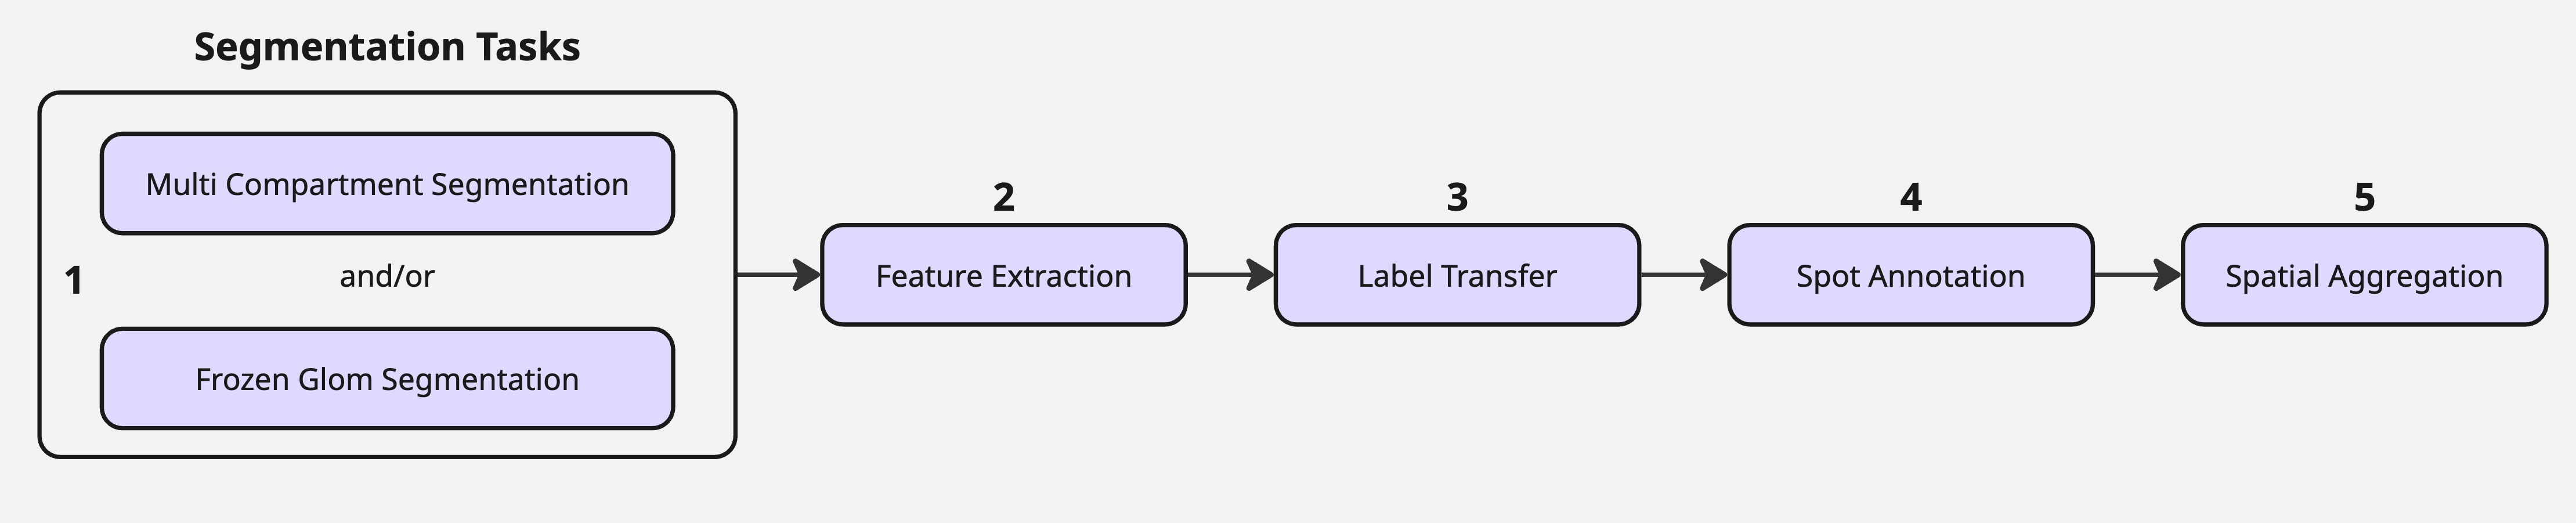

### **Code for Analysis**

#### **Parameters for Each Analysis:**

| Step | Analysis                    | Parameter              | Description                                                                 |
|------|----------------------------|------------------------|-----------------------------------------------------------------------------|
| 1    | Multicompartment Segmentation | input_file             | Path to the optimized WSI image (e.g. .tif)                                           |
|      |                            | modelfile              | Path to the segmentation model file                                         |
| 2    | Frozen Glom Segmentation   | input_image            | Path to the optimized WSI image                                                       |
|      |                            | model_file             | Path to the segmentation model file                                         |
| 3    | Feature Extraction         | input_image            | Path to the optimized WSI image                                                       |
|      |                            | annotations_dir        | Auto-derived (Segmented_FTU/ under dataset root)                            |
| 4    | Label Transfer            | counts_file            | Path to the 10X Visium counts/expression file (e.g. .h5ad)                  |
|      |                            | reference              | Path to the reference file (e.g. .h5Seurat)                                                |
|      |                            | organ                  | Hardcoded as KPMP Atlas Kidney                                              |
| 5    | Spot Annotation           | image_file             | Path to the WSI image (used only to locate dataset root)                    |
|      |                            | cell_reference_file    | Path to the cell reference file                                             |
| 6    | Spatial Aggregation       | base_annotation        | Path to the base annotation file (Spots.json)                                           |
|      |                            | agg_annotations        | One or more annotation paths (space-separated)                              |

#### **Running the Analysis Function**

Use `run_analysis()` to launch any analysis task. Choose where you want to run the analyses:

| Parameter | Description |
|---|---|
| `'notebook'` | Runs the analysis on the HuBMAP Workspace. |
| `'fusion'` | Runs the analysis on the Fusion Platform. Requires `gc` and `user_name`. |

To run in the HuBMAP Workspace: 
`run_analysis('notebook')`
> Note: To download the default Model and Reference files use: `run_analysis('notebook', gc=gc)`

To run on the Fusion Platform:
`run_analysis('fusion', gc=gc, user_name=user_name)`

In [ ]:
from fusion import run_analysis

results = run_analysis('notebook')

#### **Checking the Status of the Job**



| Code to Run | Description |
|---|---|
| `check_job_status()` | Helps the user see the status of all submitted jobs in a live-refreshing view |
| `check_job_status(mode='live')` | Shows a live-refreshing status view of all submitted jobs every 2 seconds |
| `check_job_status('{job_id}', 'live_logs')` | Helps the user see the logs for the job_id mentioned |

- job_id → The unique identifier of the job you want to monitor
- 'live' → Prints and Refreshes the job status table every 2 seconds
- 'live_logs' → Streams real-time logs/output for one specific job

> All the logs can be found under: *fusion_demo_notebooks/datasets/{_hubmap_id_of_image}/logs*

In [ ]:
from fusion import check_job_status

check_job_status()

# **Visualisation**

Use `visualize_wsi()` to visualise data in the FUSION interface.

| Parameter | Type | Description | Required |
|-----------|------|-------------|----------|
| `gc` | object | Girder client instance (only needed when using Fusion Platform) | Yes |
| `item_id` | str | Unique FUSION item ID assigned to an uploaded file. It can be found in the file's details on fusionpub platform under 'Unique ID'. Use this to visualize a specific file already uploaded to fusionpub | `item_id` (Only needed when using Fusion Platform) |
| `user` | str | Username for authentication | Yes (except when using `item_id`) |
| `dir_path` | str | Local directory path containing WSI or Visium-related output. | Required if not using `item_id` or `hubmap_id` |

> This tool can also be used to navigate the files in the Fusion Platform

To open up visual tool: `visualize_wsi(gc, user=user_name)` 

To visualise a specific item from Fusion: `visualize_wsi(gc, item_id='your_item_id', user='user_name')`

To visualise data from local directory: `visualize_wsi(gc, dir_path='/path/to/your/dataset_directory', user='user_name')`

In [ ]:
from fusion.utilities.visualize import visualize_wsi

result = visualize_wsi(gc, dir_path='', user='')
result


### Summary:
- All data added to the workspace is persisted, so it remains available when you return.
- The notebook preserves its current state, including outputs, making it easy to share workflows, while keeping your data private.
- With integrated flowcharts and documentation, it serves as an effective tool for teaching.
- With a code-based environment and available FUSION++ features, it provides a flexible platform to bring your own data, perform custom analyses, create visualizations, and build workflows tailored to your needs.